# CEAL Cross-Domain Comparison — m5c vs m8 Relabel Variants

Runs m5c, m8_naive, m8_balanced, and m8_aggressive on CEAL
with identical data pipeline and labels. Apples-to-apples comparison
of how coordinate-origin relabeling affects cross-domain transfer.

## Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# ALL PATHS
# ============================================================

DRIVE_ROOT    = "/content/drive/MyDrive/210"
ARTIFACTS_DIR = f"{DRIVE_ROOT}/ceal_gazenet_artifacts"
MANIFEST_CSV  = f"{ARTIFACTS_DIR}/manifest.csv"
GEO_PARQUET   = f"{DRIVE_ROOT}/ceal_geo_features_v1.parquet"

CHECKPOINTS = {
    'm5c':            f"{DRIVE_ROOT}/m5c.pth",
    'm8_naive':       f"{DRIVE_ROOT}/m8_naive.pth",
    'm8_balanced':    f"{DRIVE_ROOT}/m8_balanced.pth",
    'm8_aggressive':  f"{DRIVE_ROOT}/m8_aggressive.pth",
}

# Verify
for name, path in [('Manifest', MANIFEST_CSV), ('Geo parquet', GEO_PARQUET)]:
    print(f"  {name}: {'OK' if os.path.exists(path) else 'MISSING'} — {path}")
for name, path in CHECKPOINTS.items():
    print(f"  {name}: {'OK' if os.path.exists(path) else 'MISSING'} — {path}")

  Manifest: OK — /content/drive/MyDrive/210/ceal_gazenet_artifacts/manifest.csv
  Geo parquet: OK — /content/drive/MyDrive/210/ceal_geo_features_v1.parquet
  m5c: OK — /content/drive/MyDrive/210/m5c.pth
  m8_naive: OK — /content/drive/MyDrive/210/m8_naive.pth
  m8_balanced: OK — /content/drive/MyDrive/210/m8_balanced.pth
  m8_aggressive: OK — /content/drive/MyDrive/210/m8_aggressive.pth


## Load CEAL Data & Labels

In [4]:
# ============================================================
# LOAD MANIFEST — filter to aug_id=0 (unaugmented originals)
# ============================================================

manifest = pd.read_csv(MANIFEST_CSV)
print(f"Full manifest: {len(manifest)} rows")

df = manifest[(manifest['status'] == 'ok') & (manifest['aug_id'] == 0)].copy()
print(f"After filtering (status=ok, aug_id=0): {len(df)} samples")
print(f"Subjects: {df['subject'].nunique()}")

# Rewrite crop paths from SSD to Drive
OLD_ROOT = '/Volumes/Crucial X10/210/data/ceal_gazenet_artifacts'
NEW_ROOT = ARTIFACTS_DIR

for col in ['face_path', 'left_path', 'right_path']:
    df[col] = df[col].str.replace(OLD_ROOT, NEW_ROOT, regex=False)

# Verify
sample_path = df.iloc[0]['face_path']
print(f"\nSample path: {sample_path}")
print(f"  Exists: {os.path.exists(sample_path)}")

Full manifest: 5880 rows
After filtering (status=ok, aug_id=0): 5880 samples
Subjects: 56

Sample path: /content/drive/MyDrive/210/ceal_gazenet_artifacts/50/0050_2m_-30P_0V_-10H_face.jpg
  Exists: True


In [5]:
# ============================================================
# CREATE LABELS from CEAL gaze degrees
#
# !!! L/R CONVENTION FIX !!!
# CEAL's "Left" (gaze_h < 0) = m5c's "Right" (class 3)
# Without this swap, accuracy is 18.7%. With it: ~49%.
# ============================================================

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 3, 'Right': 2}  # L/R swapped
idx_to_label = {v: k for k, v in label_map_4.items()}
label_names = ['Up', 'Down', 'Right', 'Left']  # matches index order 0,1,2,3

def degrees_to_label(gaze_v, gaze_h):
    if gaze_v == 0 and gaze_h == 0:
        return 'Straight'
    if abs(gaze_h) > abs(gaze_v):
        return 'Left' if gaze_h < 0 else 'Right'
    if abs(gaze_v) > abs(gaze_h):
        return 'Down' if gaze_v < 0 else 'Up'
    return 'Left' if gaze_h < 0 else 'Right'

df['label_str'] = df.apply(
    lambda r: degrees_to_label(r['gaze_vertical_deg'], r['gaze_horizontal_deg']),
    axis=1
)

# Filter out Straight
n_before = len(df)
df = df[df['label_str'] != 'Straight'].copy()
print(f"Dropped {n_before - len(df)} Straight samples")
print(f"Remaining: {len(df)} samples (4-class)")

df['label_idx'] = df['label_str'].map(label_map_4)

print(f"\n4-class distribution:")
print(df['label_str'].value_counts())
print(f"\nLabel map (with L/R fix): {label_map_4}")

Dropped 280 Straight samples
Remaining: 5600 samples (4-class)

4-class distribution:
label_str
Left     1960
Right    1960
Down      840
Up        840
Name: count, dtype: int64

Label map (with L/R fix): {'Up': 0, 'Down': 1, 'Left': 3, 'Right': 2}


In [6]:
# ============================================================
# LOAD GEO FEATURES
# ============================================================

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['filename']] = row[geo_cols].values.astype(np.float32)

matched = df['orig_filename'].isin(geo_lookup).sum()
print(f"Geo features matched: {matched}/{len(df)} ({100*matched/len(df):.1f}%)")

Loaded geo features: 5880 rows
Geo features matched: 5600/5600 (100.0%)


## Model & Dataset Definitions

In [7]:
# ============================================================
# GazeNetM5 — identical to m5c/m8 training
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.ReLU(),
        )

        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")

GazeNetM5 defined


In [8]:
# ============================================================
# TRANSFORMS — match m5c training preprocessing
# ============================================================

eye_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

face_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

print("Transforms ready")

Transforms ready


In [9]:
# ============================================================
# CEAL DATASET
# ============================================================

class CEALDatasetM5c(Dataset):
    def __init__(self, dataframe, eye_transform, face_transform,
                 geo_lookup, geo_default):
        self.df = dataframe.reset_index(drop=True)
        self.eye_transform = eye_transform
        self.face_transform = face_transform
        self.geo_lookup = geo_lookup
        self.geo_default = geo_default

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        face      = Image.open(row['face_path']).convert('RGB')
        left_eye  = Image.open(row['left_path']).convert('RGB')
        right_eye = Image.open(row['right_path']).convert('RGB')

        face      = self.face_transform(face)
        left_eye  = self.eye_transform(left_eye)
        right_eye = self.eye_transform(right_eye)

        geo = self.geo_lookup.get(row['orig_filename'])
        if geo is None:
            geo = self.geo_default.copy()
        geo = torch.tensor(geo, dtype=torch.float32)

        label = torch.tensor(row['label_idx'], dtype=torch.long)

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': geo,
            'label': label,
        }

# Build once — shared across all models
dataset = CEALDatasetM5c(df, eye_transform, face_transform, geo_lookup, GEO_DEFAULT)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Dataset: {len(dataset)} samples")
print(f"Batches: {len(loader)}")

Dataset: 5600 samples
Batches: 88


In [10]:
# ============================================================
# SMOKE TEST
# ============================================================

batch = next(iter(loader))
print(f"left_eye:     {batch['left_eye'].shape}")
print(f"right_eye:    {batch['right_eye'].shape}")
print(f"face:         {batch['face'].shape}")
print(f"geo_features: {batch['geo_features'].shape}")
print(f"label:        {batch['label'].shape}")
print(f"label sample: {batch['label'][:8].tolist()}")

left_eye:     torch.Size([64, 3, 48, 48])
right_eye:    torch.Size([64, 3, 48, 48])
face:         torch.Size([64, 3, 112, 112])
geo_features: torch.Size([64, 7])
label:        torch.Size([64])
label sample: [3, 1, 1, 3, 2, 3, 1, 2]


## Run Inference — All Models

In [11]:
# ============================================================
# INFERENCE FUNCTION
# ============================================================

teal_cmap = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])


def run_ceal_inference(model_name, checkpoint_path):
    """Load checkpoint, run inference on CEAL, return metrics."""

    print(f"\n{'#'*60}")
    print(f"# {model_name}")
    print(f"# {checkpoint_path}")
    print(f"{'#'*60}")

    # Load model
    model = GazeNetM5(num_classes=4).to(device)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Loaded {sum(p.numel() for p in model.parameters()):,} params")

    # Inference
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=model_name):
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    accuracy = 100 * np.mean(all_preds == all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name} on CEAL — Counts (acc={accuracy:.1f}%)')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=teal_cmap,
                xticklabels=label_names, yticklabels=label_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title(f'{model_name} on CEAL — Recall per class')

    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\n{'='*50}")
    print(f"{model_name} on CEAL (4-class) — acc={accuracy:.1f}%")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=label_names))

    # Horizontal vs vertical
    h_mask = np.isin(all_labels, [2, 3])  # Right=2, Left=3
    v_mask = np.isin(all_labels, [0, 1])  # Up=0, Down=1
    h_acc = 100 * np.mean(all_preds[h_mask] == all_labels[h_mask]) if h_mask.sum() > 0 else 0
    v_acc = 100 * np.mean(all_preds[v_mask] == all_labels[v_mask]) if v_mask.sum() > 0 else 0
    print(f"Horizontal (L/R): {h_acc:.1f}%  |  Vertical (U/D): {v_acc:.1f}%")

    # Collect metrics
    p, r, f1, s = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])

    # Free GPU memory
    del model
    torch.cuda.empty_cache()

    return {
        'name': model_name,
        'accuracy': accuracy,
        'precision': dict(zip(label_names, p)),
        'recall': dict(zip(label_names, r)),
        'f1': dict(zip(label_names, f1)),
        'h_acc': h_acc,
        'v_acc': v_acc,
        'confusion_matrix': cm,
        'all_preds': all_preds,
        'all_probs': all_probs,
    }

print("run_ceal_inference() defined")

run_ceal_inference() defined



############################################################
# m5c
# /content/drive/MyDrive/210/m5c.pth
############################################################
Loaded 6,586,820 params


m5c: 100%|██████████| 88/88 [42:16<00:00, 28.82s/it]


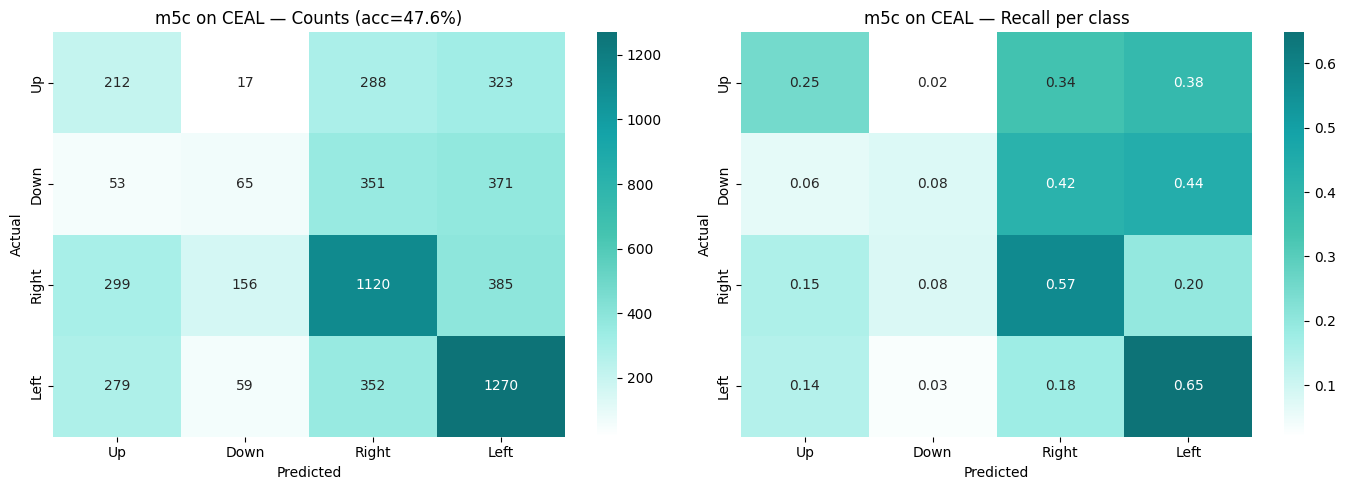


m5c on CEAL (4-class) — acc=47.6%
              precision    recall  f1-score   support

          Up       0.25      0.25      0.25       840
        Down       0.22      0.08      0.11       840
       Right       0.53      0.57      0.55      1960
        Left       0.54      0.65      0.59      1960

    accuracy                           0.48      5600
   macro avg       0.39      0.39      0.38      5600
weighted avg       0.45      0.48      0.45      5600

Horizontal (L/R): 61.0%  |  Vertical (U/D): 16.5%

############################################################
# m8_naive
# /content/drive/MyDrive/210/m8_naive.pth
############################################################
Loaded 6,586,820 params


m8_naive: 100%|██████████| 88/88 [00:58<00:00,  1.51it/s]


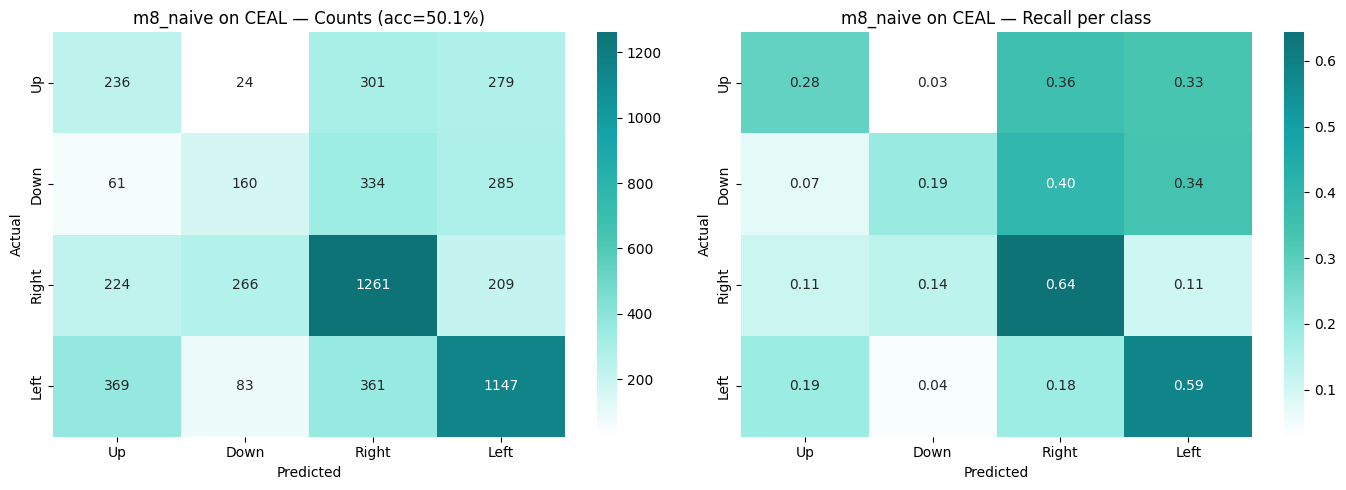


m8_naive on CEAL (4-class) — acc=50.1%
              precision    recall  f1-score   support

          Up       0.27      0.28      0.27       840
        Down       0.30      0.19      0.23       840
       Right       0.56      0.64      0.60      1960
        Left       0.60      0.59      0.59      1960

    accuracy                           0.50      5600
   macro avg       0.43      0.43      0.42      5600
weighted avg       0.49      0.50      0.49      5600

Horizontal (L/R): 61.4%  |  Vertical (U/D): 23.6%

############################################################
# m8_balanced
# /content/drive/MyDrive/210/m8_balanced.pth
############################################################
Loaded 6,586,820 params


m8_balanced: 100%|██████████| 88/88 [00:57<00:00,  1.53it/s]


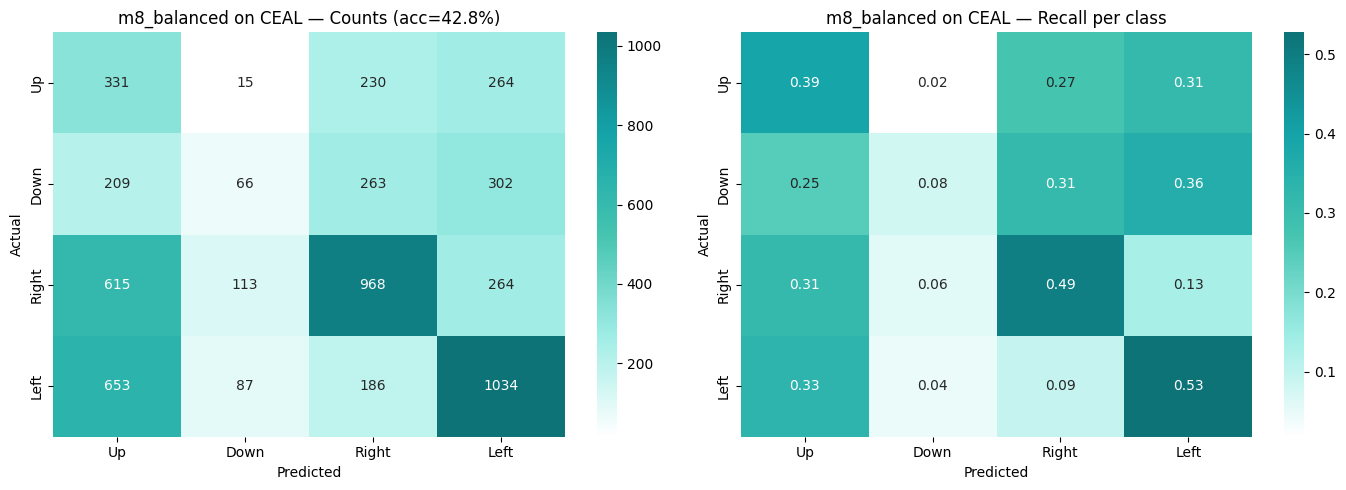


m8_balanced on CEAL (4-class) — acc=42.8%
              precision    recall  f1-score   support

          Up       0.18      0.39      0.25       840
        Down       0.23      0.08      0.12       840
       Right       0.59      0.49      0.54      1960
        Left       0.55      0.53      0.54      1960

    accuracy                           0.43      5600
   macro avg       0.39      0.37      0.36      5600
weighted avg       0.46      0.43      0.43      5600

Horizontal (L/R): 51.1%  |  Vertical (U/D): 23.6%

############################################################
# m8_aggressive
# /content/drive/MyDrive/210/m8_aggressive.pth
############################################################
Loaded 6,586,820 params


m8_aggressive: 100%|██████████| 88/88 [00:58<00:00,  1.50it/s]


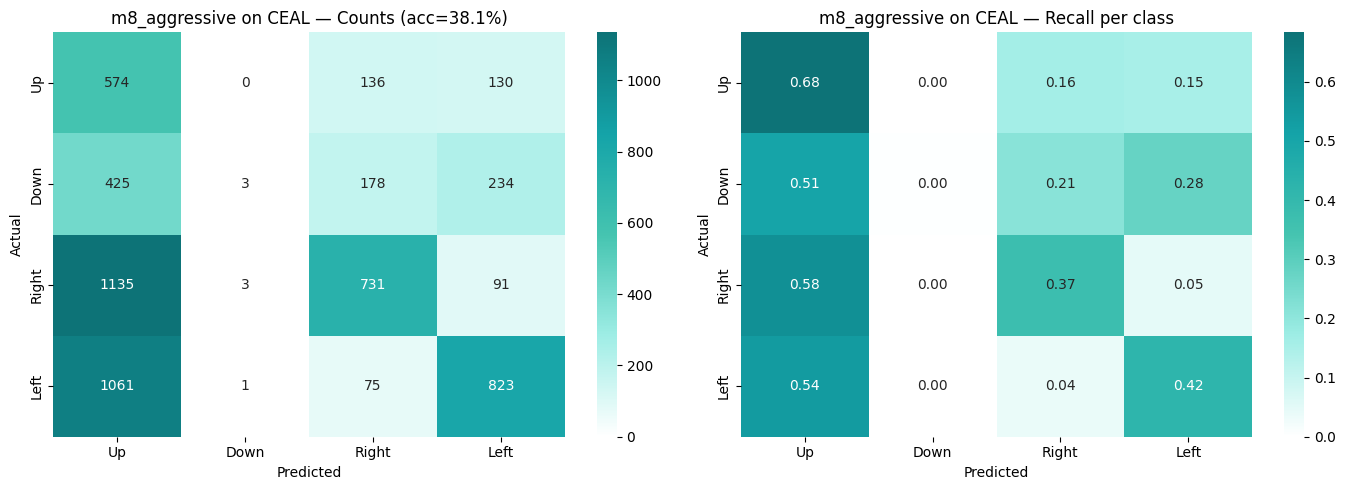


m8_aggressive on CEAL (4-class) — acc=38.1%
              precision    recall  f1-score   support

          Up       0.18      0.68      0.28       840
        Down       0.43      0.00      0.01       840
       Right       0.65      0.37      0.47      1960
        Left       0.64      0.42      0.51      1960

    accuracy                           0.38      5600
   macro avg       0.48      0.37      0.32      5600
weighted avg       0.55      0.38      0.39      5600

Horizontal (L/R): 39.6%  |  Vertical (U/D): 34.3%

ALL MODELS COMPLETE
  m5c               : 47.6%  (H=61.0%, V=16.5%)
  m8_naive          : 50.1%  (H=61.4%, V=23.6%)
  m8_balanced       : 42.8%  (H=51.1%, V=23.6%)
  m8_aggressive     : 38.1%  (H=39.6%, V=34.3%)


In [12]:
# ============================================================
# RUN ALL MODELS
# ============================================================

all_results = {}

for model_name, ckpt_path in CHECKPOINTS.items():
    if not os.path.exists(ckpt_path):
        print(f"\nSKIPPING {model_name} — checkpoint not found: {ckpt_path}")
        continue
    result = run_ceal_inference(model_name, ckpt_path)
    all_results[model_name] = result

print(f"\n{'='*60}")
print(f"ALL MODELS COMPLETE")
print(f"{'='*60}")
for name, res in all_results.items():
    print(f"  {name:18s}: {res['accuracy']:.1f}%  "
          f"(H={res['h_acc']:.1f}%, V={res['v_acc']:.1f}%)")

## Comparison

In [ ]:
# ============================================================
# SUMMARY TABLE
# ============================================================

print(f"{'Model':<18s} {'Acc':>5s}  {'Up F1':>6s} {'Dn F1':>6s} {'R F1':>6s} {'L F1':>6s}  {'H acc':>6s} {'V acc':>6s}")
print("-" * 72)
for name, res in all_results.items():
    print(f"{name:<18s} {res['accuracy']:>4.1f}%  "
          f"{res['f1']['Up']:>6.3f} {res['f1']['Down']:>6.3f} "
          f"{res['f1']['Right']:>6.3f} {res['f1']['Left']:>6.3f}  "
          f"{res['h_acc']:>5.1f}% {res['v_acc']:>5.1f}%")

In [ ]:
# ============================================================
# COMPARISON BAR CHARTS — F1 per class across all models
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'
teal_pale  = '#9EEDE5'

model_colors = {
    'm5c':           '#AAAAAA',
    'm8_naive':      teal_pale,
    'm8_balanced':   teal_mid,
    'm8_aggressive': teal_dark,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(4)  # 4 classes
n_bars = len(all_results)
width = 0.8 / n_bars

for ax, metric, title in [
    (axes[0], 'precision', 'Precision'),
    (axes[1], 'recall', 'Recall'),
    (axes[2], 'f1', 'F1-Score'),
]:
    for i, (name, res) in enumerate(all_results.items()):
        vals = [res[metric][c] for c in label_names]
        color = model_colors.get(name, '#888888')
        bars = ax.bar(x + i * width - (n_bars - 1) * width / 2, vals,
                      width, label=name, color=color, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', fontsize=6, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontweight='bold', color=teal_dark)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('CEAL Cross-Domain: m5c vs m8 Relabel Variants',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# OVERALL ACCURACY + AXIS BREAKDOWN BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(all_results.keys())
x = np.arange(len(model_names))
width = 0.25

overall = [all_results[m]['accuracy'] for m in model_names]
horiz   = [all_results[m]['h_acc'] for m in model_names]
vert    = [all_results[m]['v_acc'] for m in model_names]

bars1 = ax.bar(x - width, overall, width, label='Overall', color=teal_mid, edgecolor='white')
bars2 = ax.bar(x,         horiz,   width, label='Horizontal (L/R)', color=teal_light, edgecolor='white')
bars3 = ax.bar(x + width, vert,    width, label='Vertical (U/D)', color=teal_dark, edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=9, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('CEAL Accuracy: Overall vs Horizontal vs Vertical',
             fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CONFIDENCE ANALYSIS — per model
# ============================================================

fig, axes = plt.subplots(1, len(all_results), figsize=(6 * len(all_results), 4))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    max_probs = res['all_probs'].max(axis=1)
    correct = res['all_preds'] == np.array([r for r in df['label_idx']])

    ax.hist(max_probs[correct], bins=30, alpha=0.6, label='Correct', color='green')
    ax.hist(max_probs[~correct], bins=30, alpha=0.6, label='Incorrect', color='red')
    ax.set_xlabel('Max softmax probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Confidence', fontweight='bold', color=teal_dark)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()